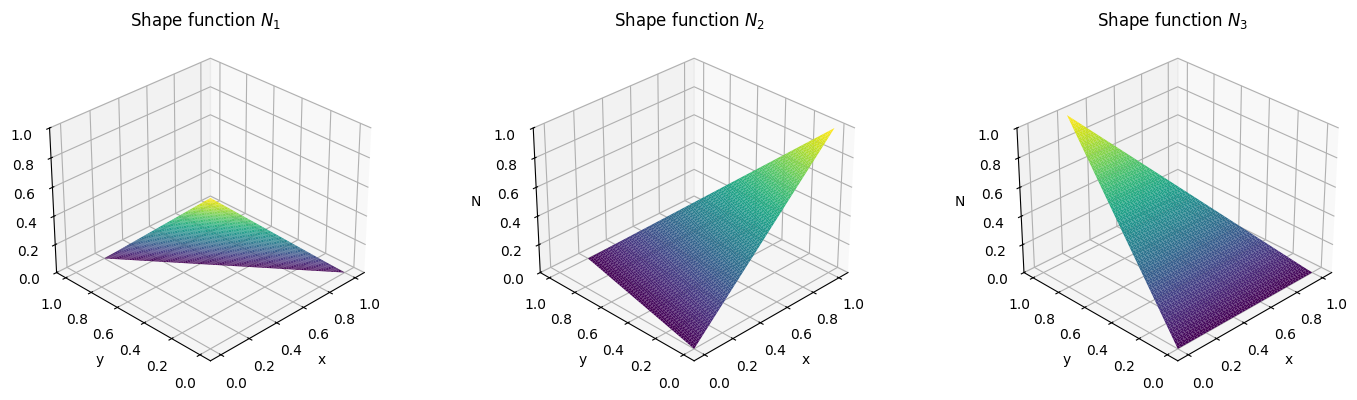

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D

def plot_shape_functions():
    # Triangle vertices (you can pick any)
    x = np.array([0.0, 1.0, 0.2])
    y = np.array([0.0, 0.0, 1.0])

    # Create grid points inside triangle using barycentric coordinates
    N = 50
    L1 = np.linspace(0, 1, N)
    L2 = np.linspace(0, 1, N)
    L1, L2 = np.meshgrid(L1, L2)
    L3 = 1 - L1 - L2

    # Keep only points inside triangle (where all λi >= 0)
    mask = (L1 >= 0) & (L2 >= 0) & (L3 >= 0)
    L1, L2, L3 = L1[mask], L2[mask], L3[mask]

    # Convert barycentric → Cartesian coordinates
    X = L1 * x[0] + L2 * x[1] + L3 * x[2]
    Y = L1 * y[0] + L2 * y[1] + L3 * y[2]

    # Shape functions are just the barycentric coordinates themselves
    N1, N2, N3 = L1, L2, L3

    # Plot each as a 3D pyramid
    fig = plt.figure(figsize=(15, 4))

    for i, (Ni, title) in enumerate(zip([N1, N2, N3], [r"$N_1$", r"$N_2$", r"$N_3$"]), 1):
        ax = fig.add_subplot(1, 3, i, projection='3d')
        ax.plot_trisurf(X, Y, Ni, cmap='viridis', linewidth=0.2)
        ax.set_title(f"Shape function {title}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("N")
        ax.set_zlim(0, 1)
        ax.view_init(elev=30, azim=-135)

    plt.tight_layout()
    plt.show()

plot_shape_functions()


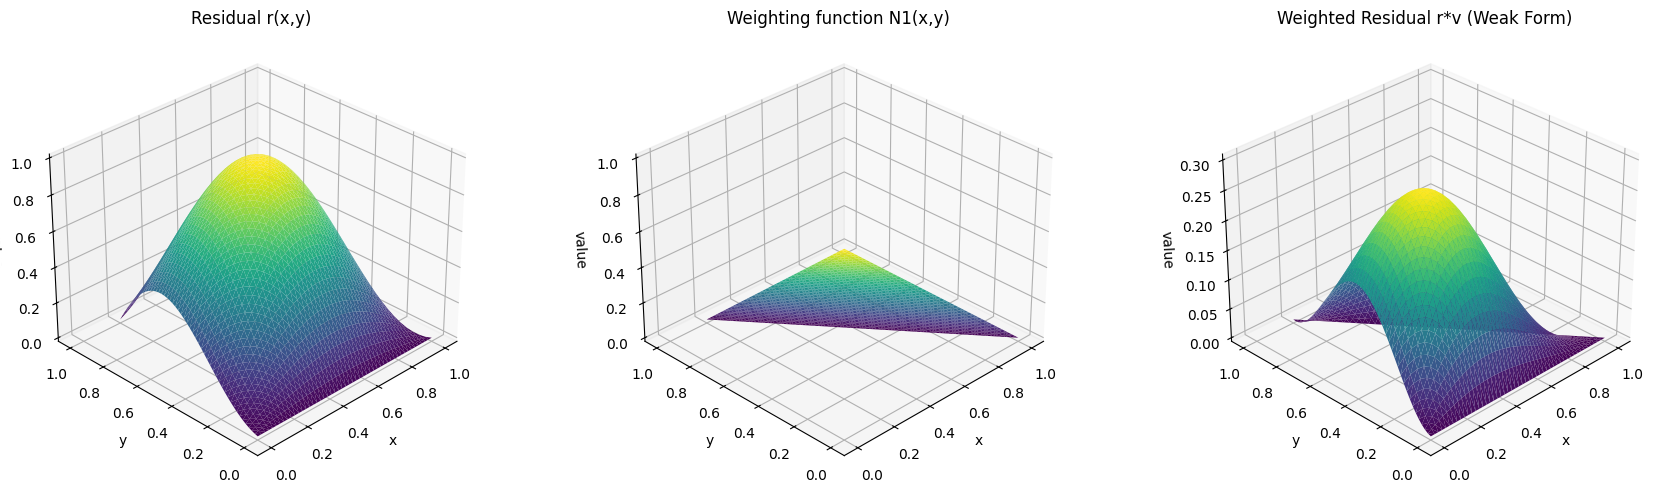

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define triangle vertices
x = np.array([0.0, 1.0, 0.2])
y = np.array([0.0, 0.0, 1.0])

# Create grid points inside the triangle using barycentric coordinates
N = 50
L1 = np.linspace(0, 1, N)
L2 = np.linspace(0, 1, N)
L1, L2 = np.meshgrid(L1, L2)
L3 = 1 - L1 - L2
mask = (L1 >= 0) & (L2 >= 0) & (L3 >= 0)
L1, L2, L3 = L1[mask], L2[mask], L3[mask]

# Cartesian coordinates
X = L1 * x[0] + L2 * x[1] + L3 * x[2]
Y = L1 * y[0] + L2 * y[1] + L3 * y[2]

# Define an artificial "residual" r(x,y) = PDE not satisfied perfectly
# Use a smooth function for demonstration
R = np.sin(np.pi * X) * np.sin(np.pi * Y)

# Shape functions (weights)
N1, N2, N3 = L1, L2, L3

# Compute weighted residuals
WR1 = R * N1
WR2 = R * N2
WR3 = R * N3

# Plotting
fig = plt.figure(figsize=(18, 5))

def plot_surface(ax, X, Y, Z, title):
    ax.plot_trisurf(X, Y, Z, cmap='viridis', linewidth=0.2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('value')
    ax.set_title(title)
    ax.view_init(elev=30, azim=-135)

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
plot_surface(ax1, X, Y, R, 'Residual r(x,y)')

ax2 = fig.add_subplot(1, 3, 2, projection='3d')
plot_surface(ax2, X, Y, N1, 'Weighting function N1(x,y)')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
plot_surface(ax3, X, Y, WR1, 'Weighted Residual r*v (Weak Form)')

plt.tight_layout()
plt.show()


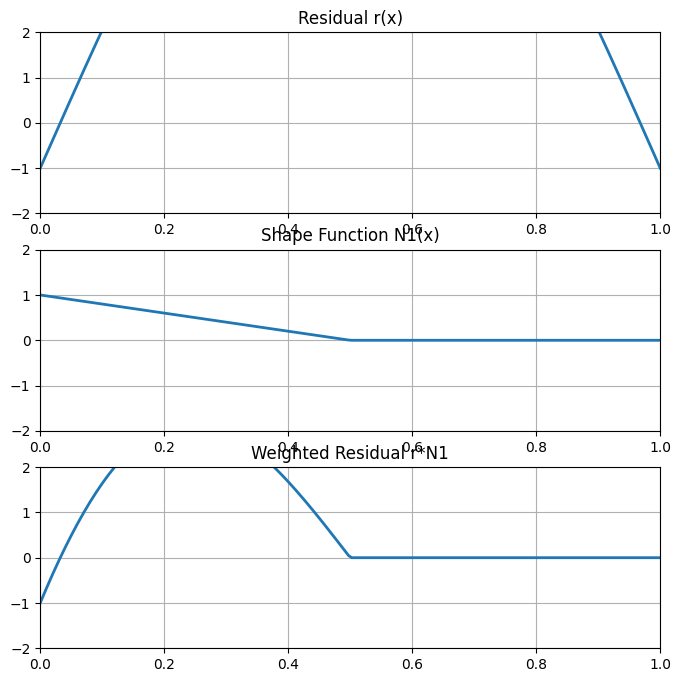

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Domain and nodes
x_nodes = np.array([0.0, 0.5, 1.0])
x_fine = np.linspace(0, 1, 200)

# Toy solution & residual
u = np.sin(np.pi * x_fine)             # pretend solution
r = np.pi**2 * np.sin(np.pi * x_fine) - 1   # toy residual

# Linear shape function for node 1 (element 1)
def N1(x):
    return np.maximum(0, (0.5 - x)/0.5)

# Weighted residual
WR1 = r * N1(x_fine)

# Set up figure
fig, axs = plt.subplots(3, 1, figsize=(8, 8))
lines = [axs[0].plot([], [], lw=2)[0],
         axs[1].plot([], [], lw=2)[0],
         axs[2].plot([], [], lw=2)[0]]

titles = ['Residual r(x)', 'Shape Function N1(x)', 'Weighted Residual r*N1']
for ax, t in zip(axs, titles):
    ax.set_xlim(0, 1)
    ax.set_ylim(-2, 2)
    ax.grid(True)
    ax.set_title(t)

# Animation function
def animate(i):
    if i == 0:
        lines[0].set_data(x_fine, r)
        lines[1].set_data(x_fine, np.zeros_like(x_fine))
        lines[2].set_data(x_fine, np.zeros_like(x_fine))
    elif i == 1:
        lines[0].set_data(x_fine, r)
        lines[1].set_data(x_fine, N1(x_fine))
        lines[2].set_data(x_fine, np.zeros_like(x_fine))
    else:
        lines[0].set_data(x_fine, r)
        lines[1].set_data(x_fine, N1(x_fine))
        lines[2].set_data(x_fine, WR1)
    return lines

anim = FuncAnimation(fig, animate, frames=3, interval=2000, blit=True)

# Display animation inline in Jupyter
HTML(anim.to_jshtml())


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

In [2]:
# ---------- 1. Physical parameters ----------
mu0 = 4 * np.pi * 1e-7   # permeability of free space
mu = mu0                 # homogeneous medium
J0 = 1e6                 # current density inside coil [A/m^2]
r_coil = 0.2             # coil radius [m]
domain_radius = 1.0      # overall domain [m]

In [3]:
# ---------- 2. Generate mesh ----------
np.random.seed(0)
n_points = 800
r = np.sqrt(np.random.rand(n_points)) * domain_radius
theta = np.random.rand(n_points) * 2 * np.pi
points = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

# Add boundary points (to close the circle)
boundary_angles = np.linspace(0, 2 * np.pi, 60)
boundary_points = np.column_stack([
    domain_radius * np.cos(boundary_angles),
    domain_radius * np.sin(boundary_angles)
])
points = np.vstack([points, boundary_points])

tri = Delaunay(points)
nodes = tri.points
elements = tri.simplices
n_nodes = len(nodes)

In [4]:
# ---------- 3. Define regions ----------
r_nodes = np.linalg.norm(nodes, axis=1)
is_coil_node = r_nodes < r_coil

# For each element, mark if its centroid lies inside coil
centroids = np.mean(nodes[elements], axis=1)
is_coil_elem = np.linalg.norm(centroids, axis=1) < r_coil

In [5]:
# ---------- 4. Assemble global stiffness matrix and load vector ----------
K = lil_matrix((n_nodes, n_nodes))
f = np.zeros(n_nodes)

for e, elem in enumerate(elements):
    coords = nodes[elem]
    x = coords[:, 0]
    y = coords[:, 1]
    
    # Area of the triangle
    A_e = 0.5 * np.linalg.det(np.array([
        [1, x[0], y[0]],
        [1, x[1], y[1]],
        [1, x[2], y[2]]
    ]))
    
    # Gradients of shape functions
    b = np.array([y[1] - y[2], y[2] - y[0], y[0] - y[1]])
    c = np.array([x[2] - x[1], x[0] - x[2], x[1] - x[0]])
    B = np.array([b, c]) / (2 * A_e)
    
    # Element stiffness matrix
    Ke = (1 / mu) * A_e * (B.T @ B)
    
    # Element load vector
    Jz = J0 if is_coil_elem[e] else 0.0
    fe = np.ones(3) * Jz * A_e / 3.0  # uniform source term
    
    # Assemble
    for i in range(3):
        for j in range(3):
            K[elem[i], elem[j]] += Ke[i, j]
        f[elem[i]] += fe[i]


In [6]:
# ---------- 5. Apply boundary conditions (A=0 at outer boundary) ----------
boundary_nodes = np.where(np.isclose(r_nodes, domain_radius, atol=1e-2))[0]
fixed = np.zeros(n_nodes, dtype=bool)
fixed[boundary_nodes] = True
free = ~fixed

# Modify system for Dirichlet BC
K_free = K[free][:, free].tocsr()
f_free = f[free]

In [7]:
# ---------- 6. Solve system ----------
A_free = spsolve(K_free, f_free)
A = np.zeros(n_nodes)
A[free] = A_free
A[fixed] = 0.0

In [8]:
# ---------- 7. Compute magnetic field ----------
# Gradient of A → B = curl(A)
Bx = np.zeros_like(A)
By = np.zeros_like(A)

for e, elem in enumerate(elements):
    coords = nodes[elem]
    x = coords[:, 0]
    y = coords[:, 1]
    A_e = 0.5 * np.linalg.det(np.array([
        [1, x[0], y[0]],
        [1, x[1], y[1]],
        [1, x[2], y[2]]
    ]))
    b = np.array([y[1] - y[2], y[2] - y[0], y[0] - y[1]])
    c = np.array([x[2] - x[1], x[0] - x[2], x[1] - x[0]])
    dA_dx = np.dot(A[elem], b) / (2 * A_e)
    dA_dy = np.dot(A[elem], c) / (2 * A_e)
    Bx[elem] += dA_dy / 3
    By[elem] -= dA_dx / 3


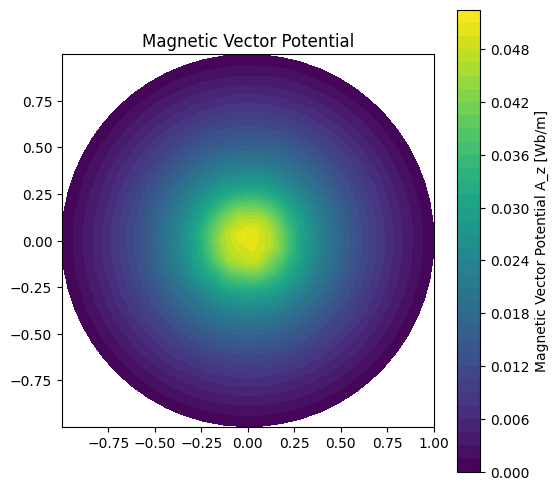

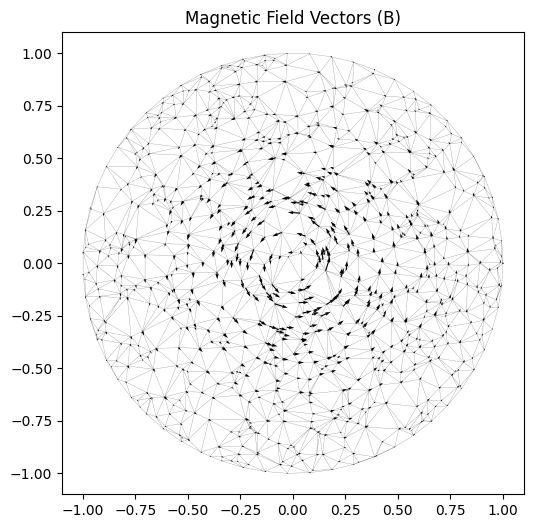

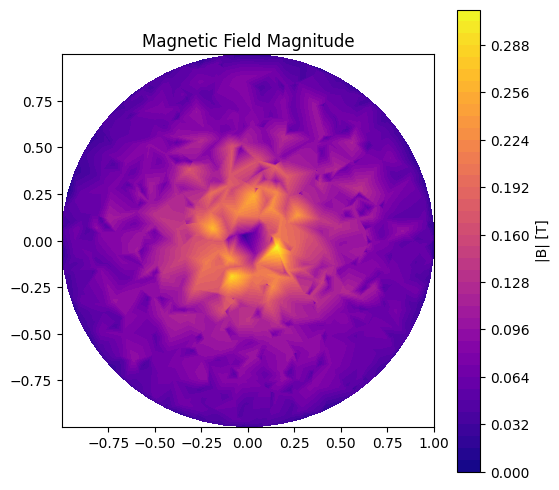

In [9]:
# ---------- 8. Plot results ----------
plt.figure(figsize=(6, 6))
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, A, 50, cmap='viridis')
plt.colorbar(label='Magnetic Vector Potential A_z [Wb/m]')
plt.title('Magnetic Vector Potential')
plt.gca().set_aspect('equal')
plt.show()

plt.figure(figsize=(6, 6))
plt.triplot(nodes[:, 0], nodes[:, 1], elements, lw=0.2, color='gray')
plt.quiver(nodes[:, 0], nodes[:, 1], Bx, By, scale=10)
plt.gca().set_aspect('equal')
plt.title('Magnetic Field Vectors (B)')
plt.show()

# Field magnitude
Bmag = np.sqrt(Bx**2 + By**2)
plt.figure(figsize=(6, 6))
plt.tricontourf(nodes[:, 0], nodes[:, 1], elements, Bmag, 50, cmap='plasma')
plt.colorbar(label='|B| [T]')
plt.gca().set_aspect('equal')
plt.title('Magnetic Field Magnitude')
plt.show()
